# Fine-tuning vs Without Fine-tuning Comparison

This notebook compares **scaffold-based** and **pharmacophore-based** metric results for generators trained with fine-tuning against the corresponding generators without fine-tuning.

## 1. Setup

This notebook is now a lightweight driver for the fine-tuning comparison workflow.
The actual implementation lives in `src/fine_tuning_comparison.py`, so the notebook only:

- initializes paths and configuration,
- optionally prepares the without-fine-tuning pharmacophore inputs,
- runs the paired comparison analysis,
- and renders the summary figures.


In [102]:
from pathlib import Path

from src.fine_tuning_comparison import build_default_config, print_config_summary

config = build_default_config(project_root=Path.cwd())
print_config_summary(config)


Project root: /home/filv/phd_projects/iga_2023/git_reccal/new/diseration_git/generative_models_for_de_novo_molecular_design
Data folder: /home/filv/phd_projects/iga_2023/git_reccal/new
Fine-tuned scaffold results: /home/filv/phd_projects/iga_2023/git_reccal/new/data/results_scaffold_based
Without fine-tuning scaffold results: /home/filv/phd_projects/iga_2023/git_reccal/new/data/generators_without_finetuning/results
Canonical PH4 metric results: /home/filv/phd_projects/iga_2023/git_reccal/new/data/results_pharm_based
Without-fine-tuning PH4 metric results: /home/filv/phd_projects/iga_2023/git_reccal/new/data/generators_without_finetuning/results_ph4_based
Output directory: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison


## 2. Optional PH4 Preparation for Without-Fine-Tuning Models

This section is only needed when the pharmacophore-based results for the without-fine-tuning models
must be copied or recomputed. In routine use, these flags can remain `False`.


In [103]:
from src.fine_tuning_comparison import (
    run_without_finetuning_ph4_metrics,
    run_without_finetuning_ph4_precompute,
    stage_without_finetuning_output_sets,
)

RUN_STAGE_WITHOUT_FT_OUTPUTS = False
RUN_WITHOUT_FT_PH4_PRECOMPUTE = False
RUN_WITHOUT_FT_PH4_METRICS = False

WITHOUT_FT_PH4_NCPUS_PRECOMPUTE = 120
WITHOUT_FT_PH4_NCPUS_METRICS = 120
WITHOUT_FT_PH4_CHUNKSIZE = 200
OVERWRITE_WITHOUT_FT_OUTPUTS = False
OVERWRITE_WITHOUT_FT_PH4 = False
SYNC_WITHOUT_FT_PH4_RESULTS = True


In [104]:
if RUN_STAGE_WITHOUT_FT_OUTPUTS:
    stage_without_finetuning_output_sets(
        config=config,
        overwrite=OVERWRITE_WITHOUT_FT_OUTPUTS,
    )
else:
    print("Output-set staging skipped. Set RUN_STAGE_WITHOUT_FT_OUTPUTS = True to copy without-fine-tuning CSV files into data/output_sets/.")

if RUN_WITHOUT_FT_PH4_PRECOMPUTE:
    run_without_finetuning_ph4_precompute(
        config=config,
        ncpus=WITHOUT_FT_PH4_NCPUS_PRECOMPUTE,
        chunksize=WITHOUT_FT_PH4_CHUNKSIZE,
        overwrite=OVERWRITE_WITHOUT_FT_PH4,
    )
else:
    print("PH4 fingerprint precomputation skipped. Set RUN_WITHOUT_FT_PH4_PRECOMPUTE = True to run it.")


Output-set staging skipped. Set RUN_STAGE_WITHOUT_FT_OUTPUTS = True to copy without-fine-tuning CSV files into data/output_sets/.
PH4 fingerprint precomputation skipped. Set RUN_WITHOUT_FT_PH4_PRECOMPUTE = True to run it.


In [105]:
if RUN_WITHOUT_FT_PH4_METRICS:
    without_ft_ph4_metrics_df = run_without_finetuning_ph4_metrics(
        config=config,
        ncpus=WITHOUT_FT_PH4_NCPUS_METRICS,
        sync_results=SYNC_WITHOUT_FT_PH4_RESULTS,
    )
    display(without_ft_ph4_metrics_df)
else:
    print("PH4 metric calculation skipped. Set RUN_WITHOUT_FT_PH4_METRICS = True after fingerprints exist.")


PH4 metric calculation skipped. Set RUN_WITHOUT_FT_PH4_METRICS = True after fingerprints exist.


## 3. Load Comparison Tables and Run the Core Analysis

The next cell loads scaffold-based and pharmacophore-based mean tables, pairs each fine-tuned
variant with its corresponding without-fine-tuning baseline, saves the long comparison tables,
and computes the win/loss summary tables used in the final figures.


In [106]:
from src.fine_tuning_comparison import run_core_analysis

analysis_outputs = run_core_analysis(config=config, save_tables=True)
comparison_df = analysis_outputs["comparison_df"]
summary_counts = analysis_outputs["summary_counts"]
missing_df = analysis_outputs["missing_df"]
paired_df = analysis_outputs["paired_df"]
best_ft_df = analysis_outputs["best_ft_df"]
stats_by_variant_df = analysis_outputs["stats_by_variant_df"]
stats_best_df = analysis_outputs["stats_best_df"]


Saved long comparison table to: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/fine_tuning_metric_values_long.csv
Loaded 288 metric rows.
Expected combinations: 288
Observed combinations: 288
Missing combinations: 0
All expected combinations are present.
Saved pairwise comparison table to: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/fine_tuning_pairwise_comparisons.csv
Saved best fine-tuned comparison table to: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/fine_tuning_best_variant_pairwise_comparisons.csv
Saved by-variant summary table to: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/fine_tuning_win_loss_counts_by_variant.csv
Saved best-variant summary table to: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/fine_tuning_win_loss_counts_best_variant.csv


## 4. Sanity Checks

This check confirms that all expected combinations of
`model + variant + receptor + structural_unit + split + metric`
were loaded before interpreting the paired comparison results.


In [107]:
display(summary_counts)
if not missing_df.empty:
    display(missing_df)


,model,variant,receptor,structural_unit,split,n_metric_rows
0,DrugEx_GT,epsilon_0.1_250k,Glucocorticoid_receptor,CSK,dis,3
1,DrugEx_GT,epsilon_0.1_250k,Glucocorticoid_receptor,CSK,sim,3
2,DrugEx_GT,epsilon_0.1_250k,Glucocorticoid_receptor,MURCKO,dis,3
3,DrugEx_GT,epsilon_0.1_250k,Glucocorticoid_receptor,MURCKO,sim,3
4,DrugEx_GT,epsilon_0.1_250k,Glucocorticoid_receptor,pharmacophore fingerprint,dis,3
...,...,...,...,...,...,...
91,REINVENT,without_fine_tuning,Leukocyte_elastase,CSK,sim,3
92,REINVENT,without_fine_tuning,Leukocyte_elastase,MURCKO,dis,3
93,REINVENT,without_fine_tuning,Leukocyte_elastase,MURCKO,sim,3
94,REINVENT,without_fine_tuning,Leukocyte_elastase,pharmacophore fingerprint,dis,3


## 5. Paired Statistical Comparison

Each fine-tuned variant is paired with the corresponding without-fine-tuning result by:

`model + receptor + structural_unit + split + metric`

The main difference is computed as:

`delta = fine_tuned - without_fine_tuning`

Positive delta means the fine-tuned variant performed better.


In [108]:
display(paired_df.head())
display(best_ft_df.head())


,model,receptor,receptor_label,structural_unit,unit_code,representation_family,split,metric,variant,variant_label,fine_tuned_value,without_value,delta_fine_minus_without,winner
0,DrugEx_GT,Glucocorticoid_receptor,Glucocorticoid receptor,pharmacophore fingerprint,rdkit,ph4,dis,ASER,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",0.015929,0.015278,0.000651,fine_tuned
1,DrugEx_GT,Glucocorticoid_receptor,Glucocorticoid receptor,pharmacophore fingerprint,rdkit,ph4,sim,ASER,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",0.007656,0.018015,-0.010359,without_fine_tuning
2,DrugEx_GT,Leukocyte_elastase,Leukocyte elastase,pharmacophore fingerprint,rdkit,ph4,dis,ASER,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",0.146727,0.203263,-0.056536,without_fine_tuning
3,DrugEx_GT,Leukocyte_elastase,Leukocyte elastase,pharmacophore fingerprint,rdkit,ph4,sim,ASER,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",0.062912,0.070704,-0.007792,without_fine_tuning
4,DrugEx_GT,Glucocorticoid_receptor,Glucocorticoid receptor,pharmacophore fingerprint,rdkit,ph4,dis,RS,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",0.387361,0.374507,0.012854,fine_tuned


,model,receptor,receptor_label,structural_unit,unit_code,representation_family,split,metric,variant,variant_label,fine_tuned_value,without_value,delta_fine_minus_without,winner
0,DrugEx_GT,Glucocorticoid_receptor,Glucocorticoid receptor,pharmacophore fingerprint,rdkit,ph4,dis,ASER,fine_tuned_best,best fine-tuned,0.058677,0.015278,0.043399,fine_tuned
1,DrugEx_GT,Glucocorticoid_receptor,Glucocorticoid receptor,pharmacophore fingerprint,rdkit,ph4,sim,ASER,fine_tuned_best,best fine-tuned,0.044631,0.018015,0.026616,fine_tuned
2,DrugEx_GT,Leukocyte_elastase,Leukocyte elastase,pharmacophore fingerprint,rdkit,ph4,dis,ASER,fine_tuned_best,best fine-tuned,0.403402,0.203263,0.200138,fine_tuned
3,DrugEx_GT,Leukocyte_elastase,Leukocyte elastase,pharmacophore fingerprint,rdkit,ph4,sim,ASER,fine_tuned_best,best fine-tuned,0.178745,0.070704,0.108041,fine_tuned
4,DrugEx_GT,Glucocorticoid_receptor,Glucocorticoid receptor,pharmacophore fingerprint,rdkit,ph4,dis,RS,fine_tuned_best,best fine-tuned,0.629774,0.374507,0.255266,fine_tuned


In [109]:
display(stats_by_variant_df)
display(stats_best_df)


,model,variant,variant_label,metric,structural_unit,unit_code,representation_family,n_pairs,fine_tuned_better,without_better,ties,fine_tuned_win_rate,mean_delta_fine_minus_without,median_delta_fine_minus_without,wilcoxon_statistic,wilcoxon_p_two_sided,wilcoxon_p_fine_tuned_greater
0,DrugEx_GT,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",ASER,pharmacophore fingerprint,rdkit,ph4,4,1,3,0,0.25,-0.018509,-0.009076,1.0,0.250,0.9375
1,DrugEx_GT,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",RS,pharmacophore fingerprint,rdkit,ph4,4,1,3,0,0.25,-0.080372,-0.060046,1.0,0.250,0.9375
2,DrugEx_GT,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",SED,pharmacophore fingerprint,rdkit,ph4,4,0,4,0,0.00,-0.029529,-0.031007,0.0,0.125,1.0000
3,DrugEx_GT,epsilon_0.6_250k,"fine-tuned, epsilon 0.6",ASER,pharmacophore fingerprint,rdkit,ph4,4,4,0,0,1.00,0.094549,0.075720,0.0,0.125,0.0625
4,DrugEx_GT,epsilon_0.6_250k,"fine-tuned, epsilon 0.6",RS,pharmacophore fingerprint,rdkit,ph4,4,3,1,0,0.75,0.155276,0.186163,1.0,0.250,0.1250
5,DrugEx_GT,epsilon_0.6_250k,"fine-tuned, epsilon 0.6",SED,pharmacophore fingerprint,rdkit,ph4,4,0,4,0,0.00,-0.027109,-0.024626,0.0,0.125,1.0000
6,DrugEx_RNN,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",ASER,pharmacophore fingerprint,rdkit,ph4,4,4,0,0,1.00,0.007720,0.004134,0.0,0.125,0.0625
7,DrugEx_RNN,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",RS,pharmacophore fingerprint,rdkit,ph4,4,0,4,0,0.00,-0.224240,-0.177884,0.0,0.125,1.0000
8,DrugEx_RNN,epsilon_0.1_250k,"fine-tuned, epsilon 0.1",SED,pharmacophore fingerprint,rdkit,ph4,4,0,4,0,0.00,-0.024287,-0.020493,0.0,0.125,1.0000
9,DrugEx_RNN,epsilon_0.6_250k,"fine-tuned, epsilon 0.6",ASER,pharmacophore fingerprint,rdkit,ph4,4,4,0,0,1.00,0.097953,0.070806,0.0,0.125,0.0625


,model,variant,variant_label,metric,structural_unit,unit_code,representation_family,n_pairs,fine_tuned_better,without_better,ties,fine_tuned_win_rate,mean_delta_fine_minus_without,median_delta_fine_minus_without,wilcoxon_statistic,wilcoxon_p_two_sided,wilcoxon_p_fine_tuned_greater
0,DrugEx_GT,fine_tuned_best,best fine-tuned,ASER,pharmacophore fingerprint,rdkit,ph4,4,4,0,0,1.00,0.094549,0.075720,0.0,0.125,0.0625
1,DrugEx_GT,fine_tuned_best,best fine-tuned,RS,pharmacophore fingerprint,rdkit,ph4,4,3,1,0,0.75,0.155276,0.186163,1.0,0.250,0.1250
2,DrugEx_GT,fine_tuned_best,best fine-tuned,SED,pharmacophore fingerprint,rdkit,ph4,4,0,4,0,0.00,-0.019727,-0.019348,0.0,0.125,1.0000
3,DrugEx_RNN,fine_tuned_best,best fine-tuned,ASER,pharmacophore fingerprint,rdkit,ph4,4,4,0,0,1.00,0.097953,0.070806,0.0,0.125,0.0625
4,DrugEx_RNN,fine_tuned_best,best fine-tuned,RS,pharmacophore fingerprint,rdkit,ph4,4,2,2,0,0.50,0.108665,0.068928,3.0,0.625,0.3125
5,DrugEx_RNN,fine_tuned_best,best fine-tuned,SED,pharmacophore fingerprint,rdkit,ph4,4,0,4,0,0.00,-0.012738,-0.010218,0.0,0.125,1.0000
6,REINVENT,fine_tuned_best,best fine-tuned,ASER,pharmacophore fingerprint,rdkit,ph4,4,4,0,0,1.00,0.050146,0.029525,0.0,0.125,0.0625
7,REINVENT,fine_tuned_best,best fine-tuned,RS,pharmacophore fingerprint,rdkit,ph4,4,3,1,0,0.75,0.015399,0.036461,4.0,0.875,0.4375
8,REINVENT,fine_tuned_best,best fine-tuned,SED,pharmacophore fingerprint,rdkit,ph4,4,0,4,0,0.00,-0.257632,-0.257735,0.0,0.125,1.0000
9,DrugEx_GT,fine_tuned_best,best fine-tuned,ASER,CSK,csk,scaffold,4,1,3,0,0.25,-0.001663,-0.002040,2.0,0.375,0.8750


## 5a. Visualize Scaffold-Based Metric Values

The 2 × 4 plots show both receptors as rows and scaffold/split combinations as columns.
This section is scaffold-based only and does not include pharmacophore-based results.
ASER can optionally be scaled only for visualization so it is visible next to RS and SED.


Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/DrugEx_RNN_scaffold_metric_bars.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/DrugEx_RNN_scaffold_metric_bars.svg
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/DrugEx_GT_scaffold_metric_bars.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/DrugEx_GT_scaffold_metric_bars.svg
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/REINVENT_scaffold_metric_bars.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/REINVENT_scaffold_metric_bars.svg


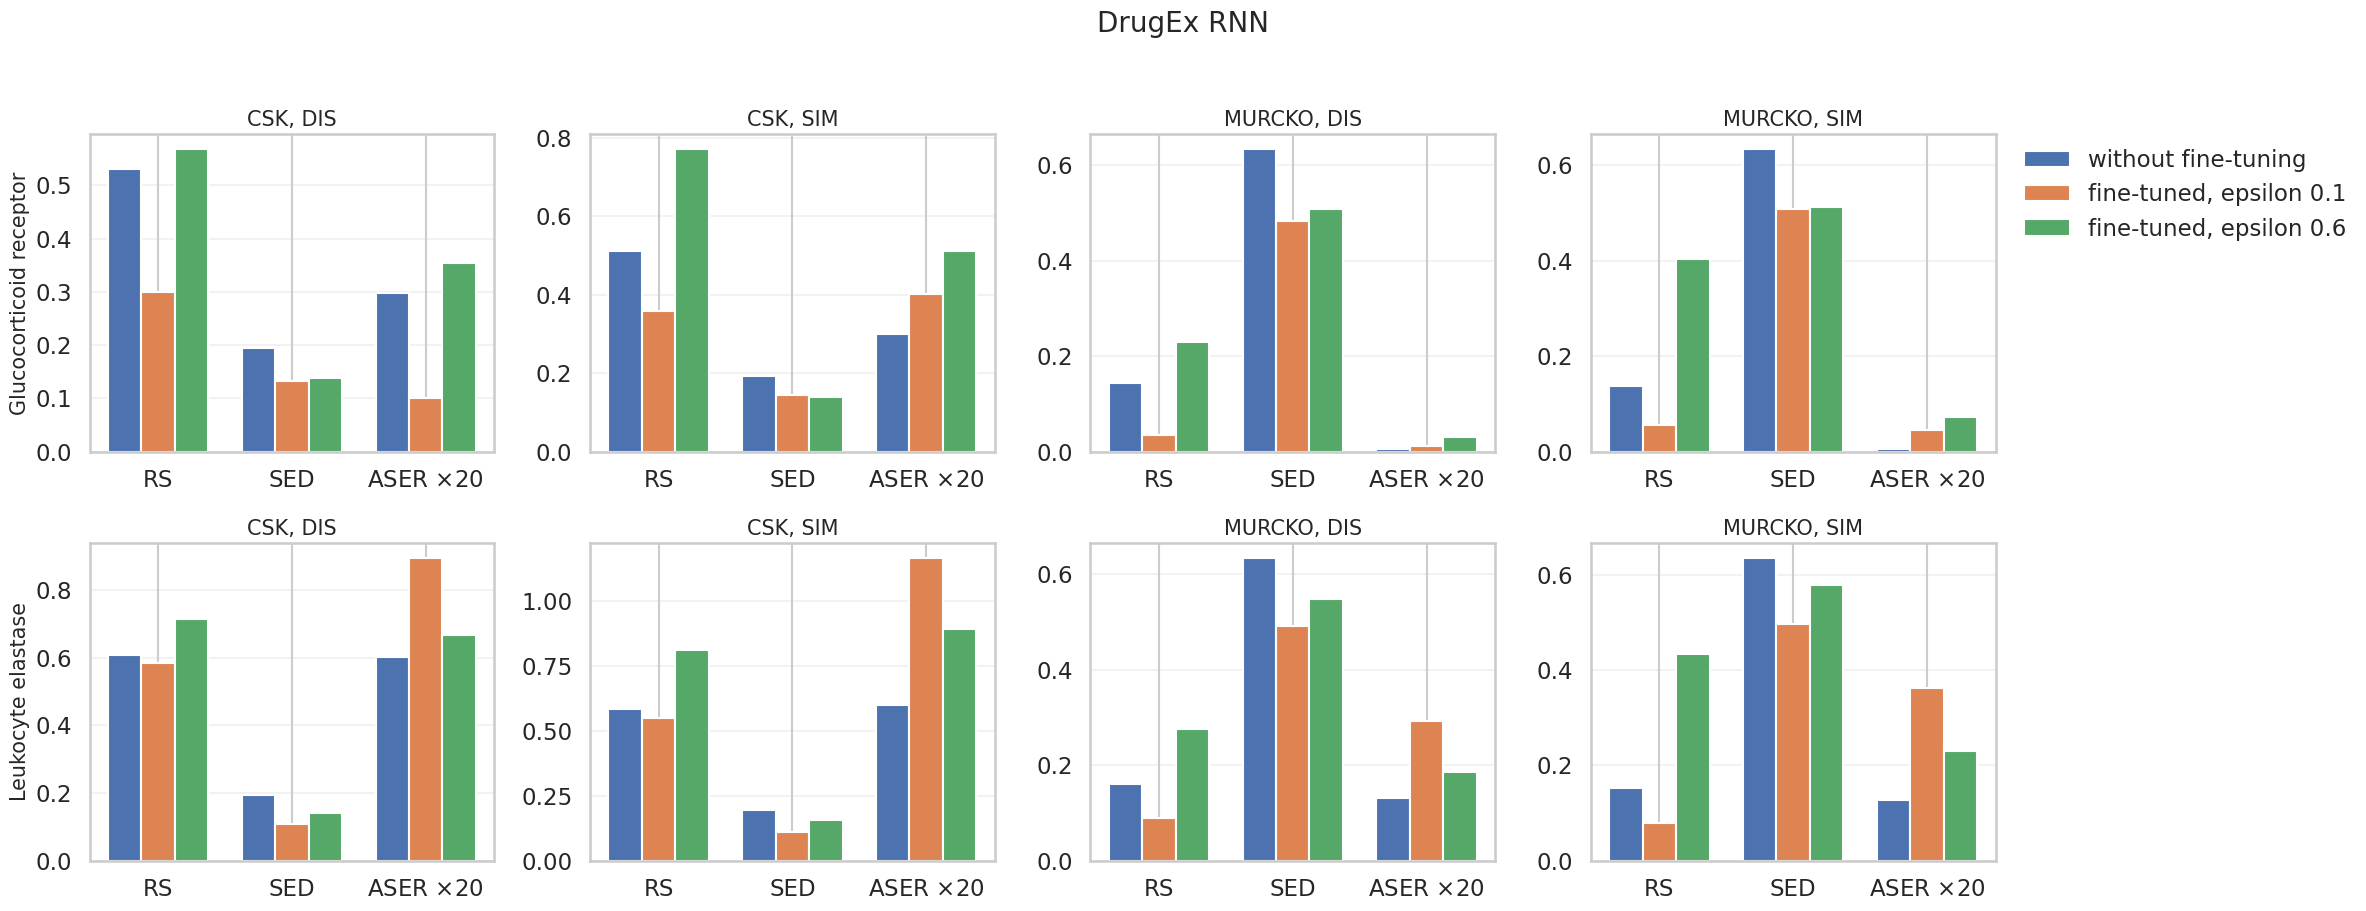

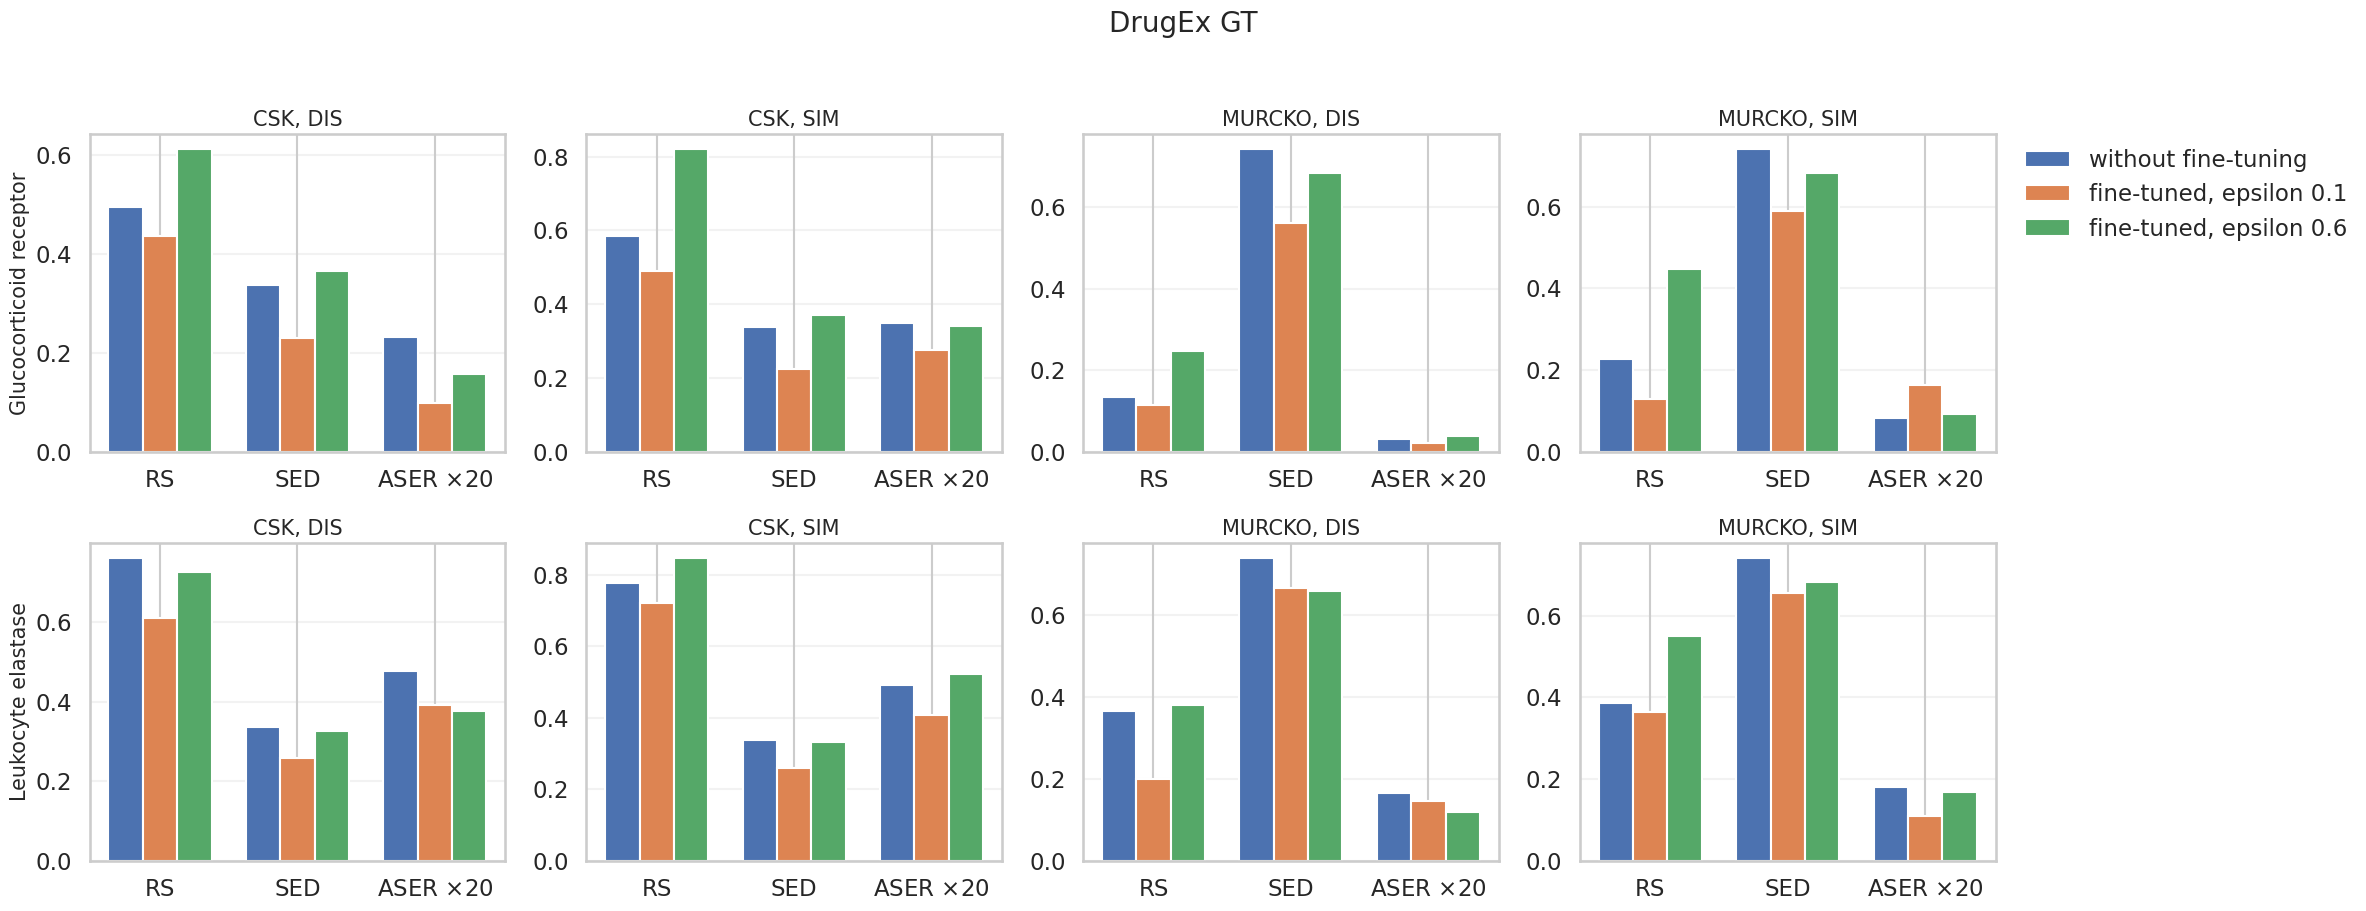

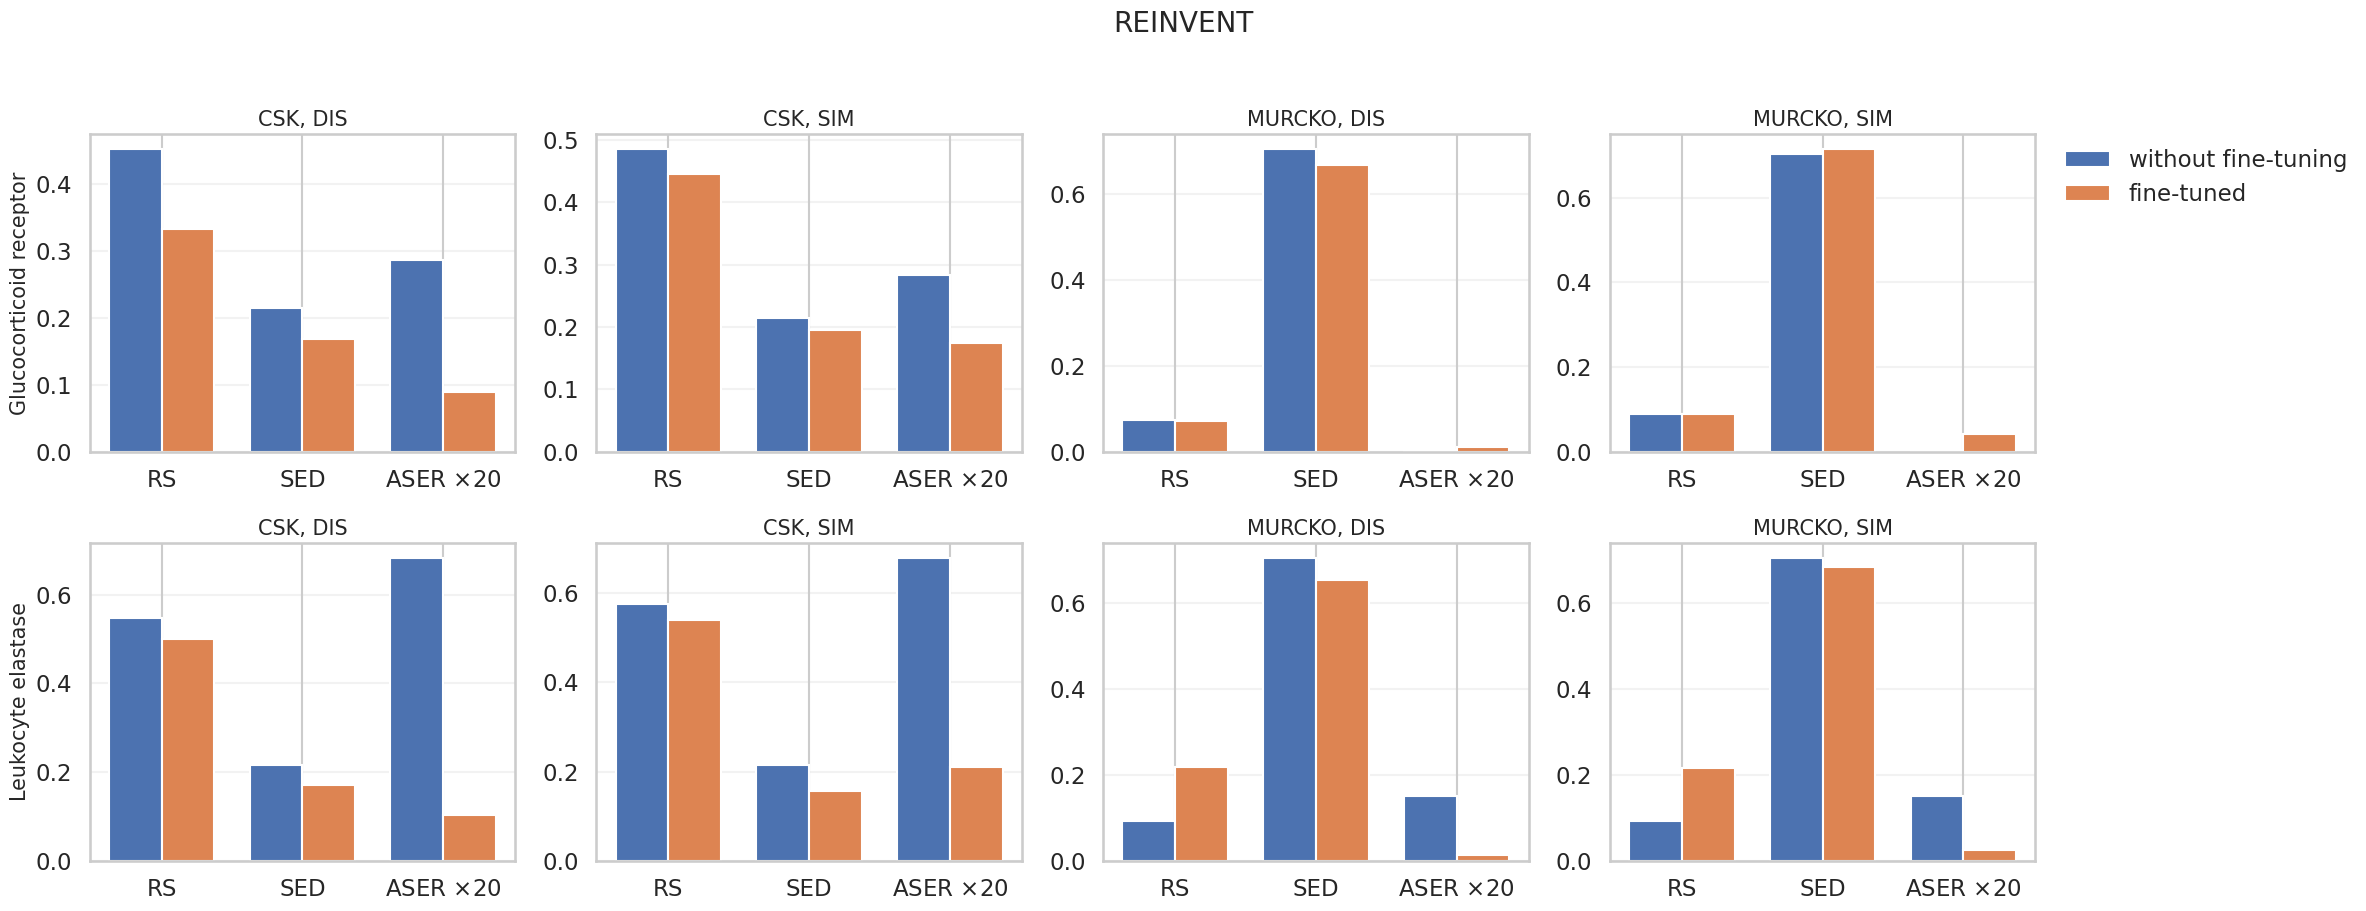

In [110]:
import matplotlib.pyplot as plt

from src.fine_tuning_comparison import plot_scaffold_metric_bar_grid

scaffold_figures = plot_scaffold_metric_bar_grid(
    comparison_df=comparison_df,
    config=config,
    aser_scale=20.0,
    save=True,
)

for fig in scaffold_figures.values():
    display(fig)
    plt.close(fig)


## 6. One-Figure Summary by Structural Unit and Metric

This figure summarizes all win/loss counts across both scaffold-based and pharmacophore-based metrics.
Rows correspond to structural units (`CSK`, `MURCKO`, `pharmacophore fingerprint`)
and columns correspond to the three metrics (`RS`, `SED`, `ASER`).
Within each panel, bar lengths show how many experimental settings were better for the
fine-tuned model versus the corresponding without-fine-tuning baseline.


Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/fine_tuning_win_loss_by_structural_unit_and_metric.png
Saved: /home/filv/phd_projects/iga_2023/git_reccal/new/data/fine_tuning_comparison/fine_tuning_win_loss_by_structural_unit_and_metric.svg


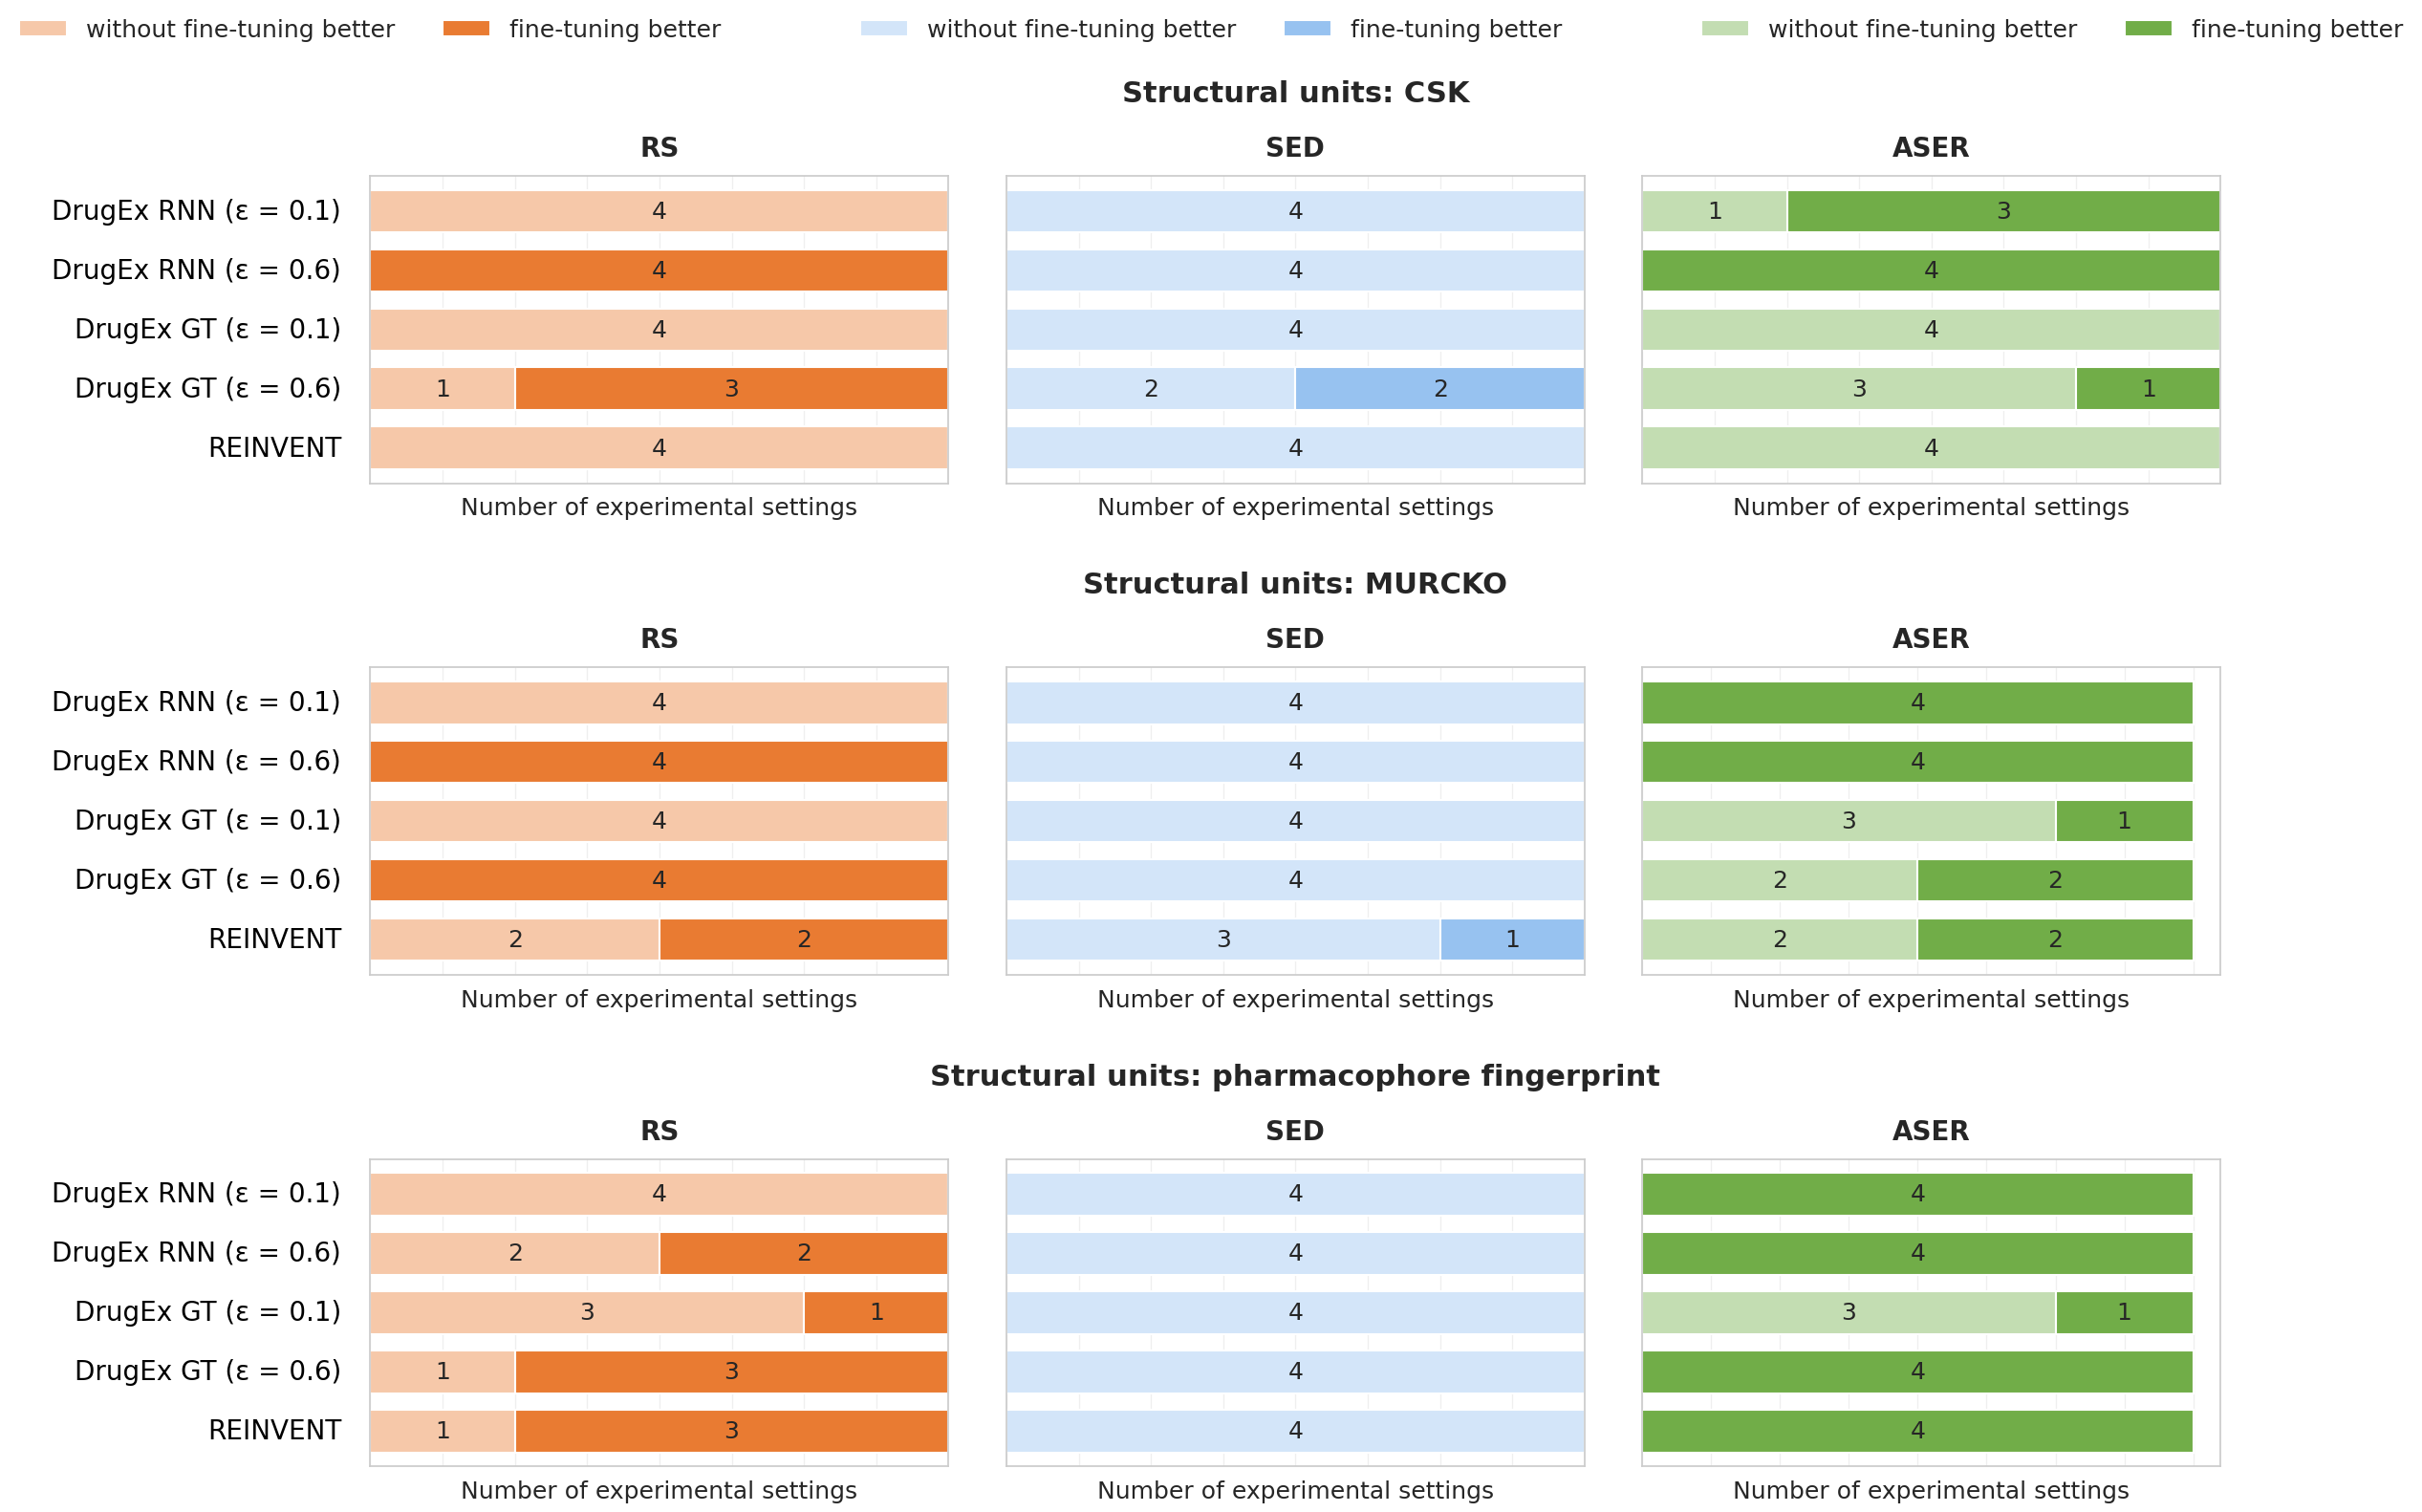

In [111]:
import matplotlib.pyplot as plt

from src.fine_tuning_comparison import plot_finetuning_win_loss_by_structural_unit

combined_fig = plot_finetuning_win_loss_by_structural_unit(
    stats_df=stats_by_variant_df,
    output_dir=config.output_dir,
    save=True,
)

if combined_fig is not None:
    display(combined_fig)
    plt.close(combined_fig)
